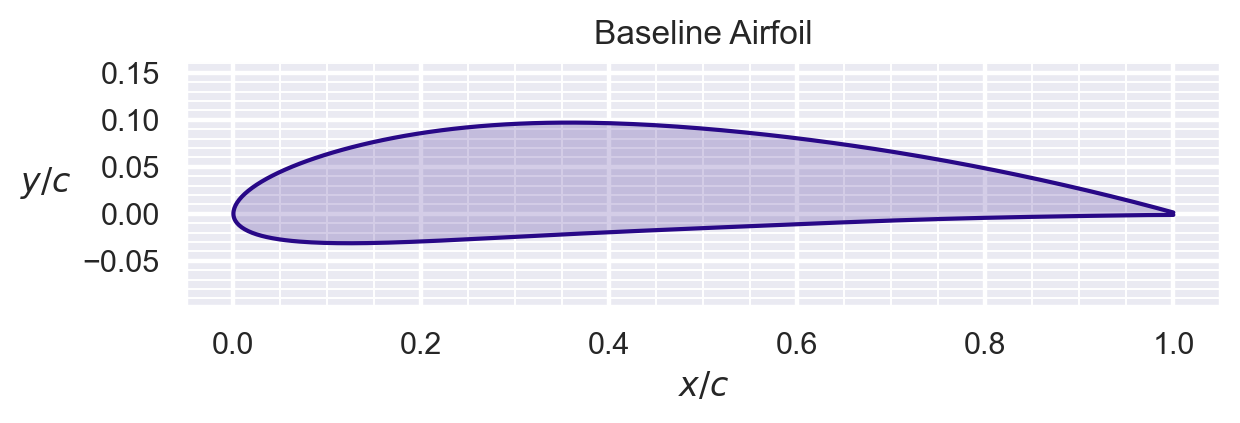

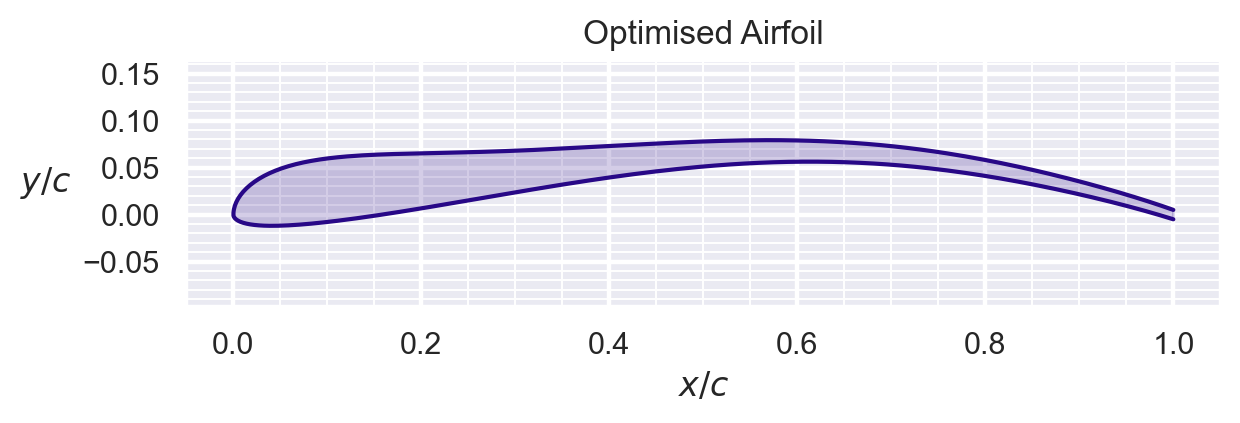

In [4]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt
import aerosandbox.tools.pretty_plots as p

baseline= asb.KulfanAirfoil(
    name="Baseline",
    lower_weights= [-0.16965146, -0.09364138, -0.06345896, -0.0067966, -0.0902447,  0.02081845, -0.03575216, -0.00223623],
    upper_weights= [0.18109497, 0.21268419, 0.28098503, 0.24864887, 0.2402814, 0.27262843, 0.25776474, 0.27817638],
    leading_edge_weight=0.10647,
    TE_thickness=0.00257,
)

optimised= asb.KulfanAirfoil(
    name="Optimised",
    lower_weights=[ -0.10264578461647034, -0.002956927753984928, 0.04788283631205559, 0.14223960041999817, 0.15873770415782928,0.28605443239212036, 0.23426659405231476, 0.31003499031066895],
    upper_weights=[0.23543250560760495, 0.16666221618652344, 0.11111072450876236, 0.19317159056663513, 0.20873770117759705, 0.3360544443130493, 0.2842665910720825,0.3600350022315979],
    leading_edge_weight=0.10302258282899857,
    TE_thickness=0.009999999776482582,
)
fig, ax = plt.subplots(figsize=(6, 2))
baseline.draw()
fig, ax = plt.subplots(figsize=(6, 2))
optimised.draw()

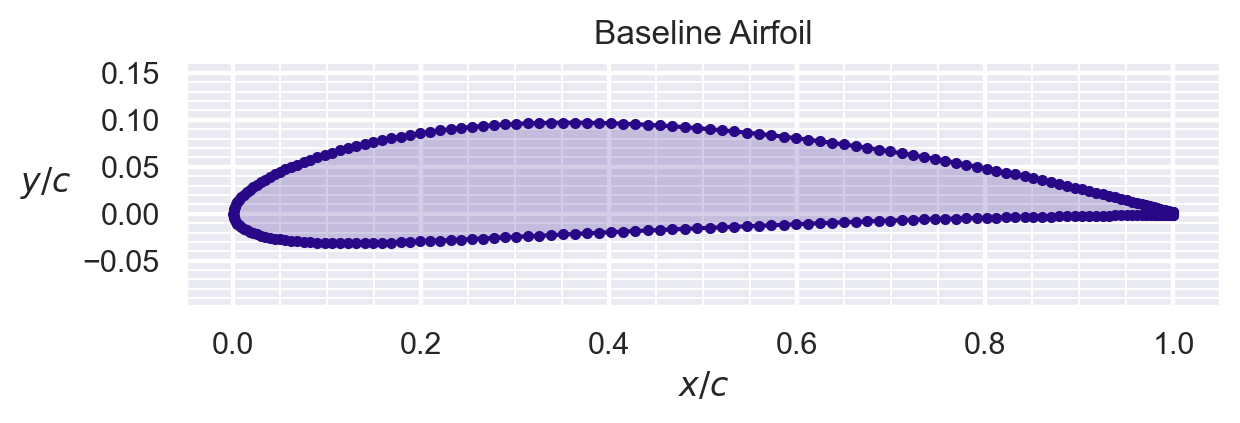

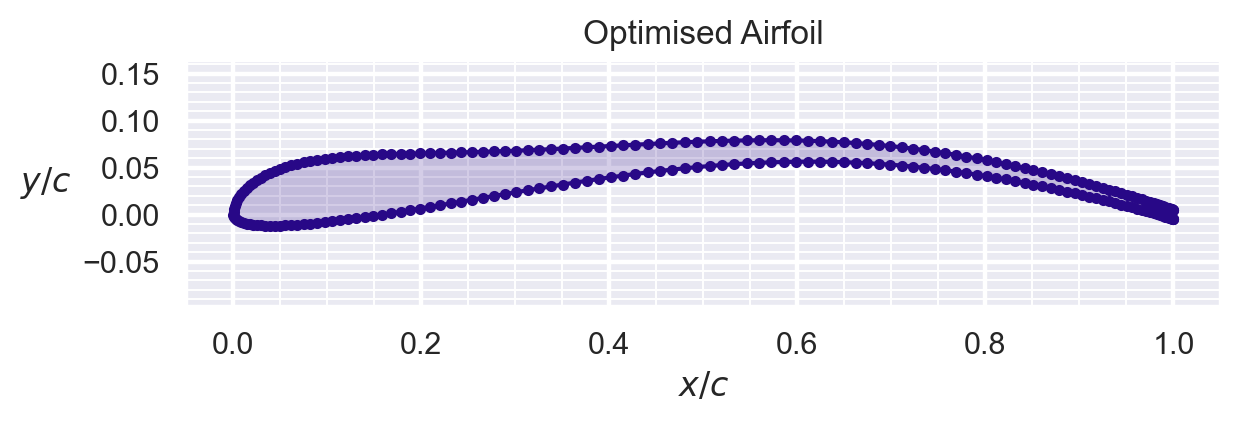

In [16]:
baseline_dat=baseline.to_airfoil(n_coordinates_per_side=120)
optimised_dat=optimised.to_airfoil(n_coordinates_per_side=120)
fig, ax = plt.subplots(figsize=(6, 2))
baseline_dat.draw()
fig, ax = plt.subplots(figsize=(6, 2))
optimised_dat.draw()

In [18]:
from pathlib import Path
import numpy as np

# Export target (same folder as DP_Spencer_K60.dat)
out_dir = Path("/Users/gherardi/Documents/GitHub/glider_optimization/aero_rom/data")
out_dir.mkdir(parents=True, exist_ok=True)

def export_airfoil_dat(airfoil_obj, out_path: Path, header_name: str | None = None):
    """
    Export Airfoil coordinates to .dat with formatting like DP_Spencer_K60.dat:
      - First line: airfoil name
      - Following lines: ' xxxxxxx.xxxxxxx     yyyyyyy.yyyyyyy' (7 decimals)
    """
    coords = np.asarray(airfoil_obj.coordinates, dtype=float)
    name = header_name if header_name is not None else str(getattr(airfoil_obj, "name", out_path.stem))

    lines = [name]
    for x, y in coords:
        lines.append(f" {x:.7f}     {y:.7f}")

    out_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return out_path

# Export both airfoils created above
baseline_path = export_airfoil_dat(baseline_dat, out_dir / f"{baseline_dat.name}.dat")
optimised_path = export_airfoil_dat(optimised_dat, out_dir / f"{optimised_dat.name}.dat")

print("Exported:")
print(f"- {baseline_path}")
print(f"- {optimised_path}")

Exported:
- /Users/gherardi/Documents/GitHub/glider_optimization/aero_rom/data/Baseline.dat
- /Users/gherardi/Documents/GitHub/glider_optimization/aero_rom/data/Optimised.dat
